**LAB 2**\
Machine Learning with** Scikit-Learn Basics**\
CS4082 – **Machine Learning**\
Prepared by: **Dr. Naila Marir**

**Part 1: Setting Up Your Environment**

In [2]:
import sklearn
print(f"scikit-learn version: {sklearn.__version__}:")
import numpy as np
import matplotlib.pyplot as plt
print("All libraries loaded successfully!")


scikit-learn version: 1.6.1:
All libraries loaded successfully!


3.2 Step 1: Load the Dataset


In [4]:
from sklearn.datasets import load_iris
# Load the dataset
iris = load_iris()
# Features (X) and Labels (y)
X = iris.data # Shape: (150, 4)
y = iris.target # Shape: (150,)
# Let"s see what we have
print(f"Feature names: {iris.feature_names}")
print(f"Target names: {iris.target_names}")
print(f"Data shape: {X.shape}")
print(f"First 3 rows:\n{X[:3]}")


Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)
First 3 rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


3.3 Step 2: Quick Visualization


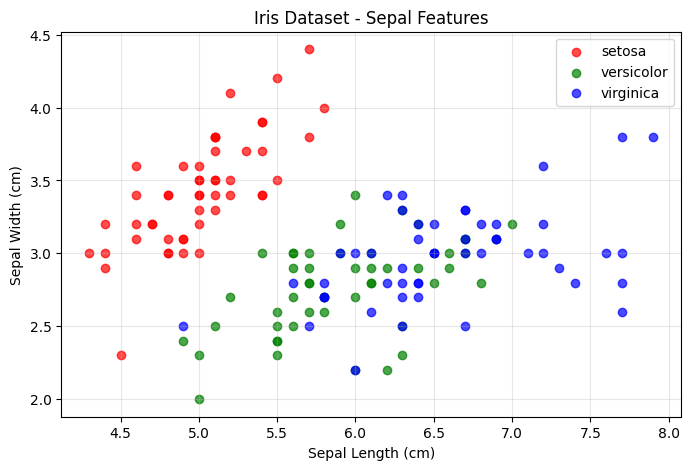

In [8]:
plt.figure(figsize=(8, 5))
colors = ["red", "green", "blue"]
for i, name in enumerate(iris.target_names):
  mask = y == i
  plt.scatter(X[mask, 0], X[mask, 1],
      color=colors[i], label=name, alpha=0.7)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Iris Dataset - Sepal Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Task 1 : Explore the Data

First 10 rows [Sepal L, Sepal W, Petal L, Petal W | Target]:
[[5.1 3.5 1.4 0.2 0. ]
 [4.9 3.  1.4 0.2 0. ]
 [4.7 3.2 1.3 0.2 0. ]
 [4.6 3.1 1.5 0.2 0. ]
 [5.  3.6 1.4 0.2 0. ]
 [5.4 3.9 1.7 0.4 0. ]
 [4.6 3.4 1.4 0.3 0. ]
 [5.  3.4 1.5 0.2 0. ]
 [4.4 2.9 1.4 0.2 0. ]
 [4.9 3.1 1.5 0.1 0. ]]

Class Distribution: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}


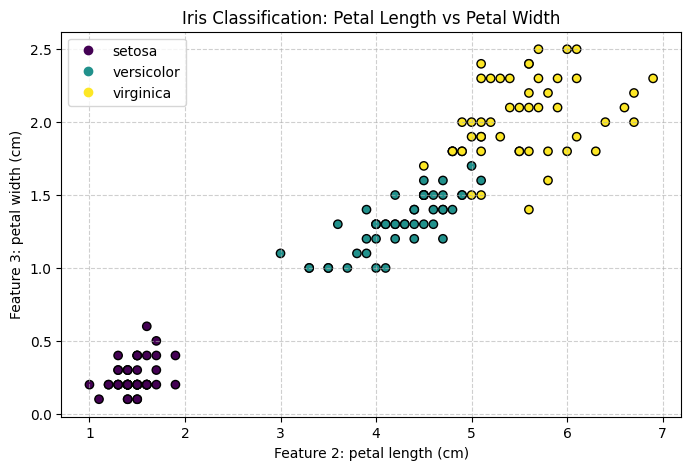

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 1. Load the dataset
iris = load_iris()
X, y = iris.data, iris.target

# 2. Print first 10 rows of X and y side by side
print("First 10 rows [Sepal L, Sepal W, Petal L, Petal W | Target]:")
# Reshape y to (150, 1) so it can be stacked horizontally with X
combined = np.hstack((X[:10], y[:10].reshape(-1, 1)))
print(combined)

# 3. Check class distribution
classes, counts = np.unique(y, return_counts=True)
print(f"\nClass Distribution: {dict(zip(iris.target_names, counts))}")

# 4. Create scatter plot: Petal Length (col 2) vs Petal Width (col 3)
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X[:, 2], X[:, 3], c=y, cmap='viridis', edgecolors='k')

# Add labels and legend
plt.xlabel(f"Feature 2: {iris.feature_names[2]}")
plt.ylabel(f"Feature 3: {iris.feature_names[3]}")
plt.title("Iris Classification: Petal Length vs Petal Width")
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

4.2 Splitting with Scikit-Learn


In [9]:
from sklearn.model_selection import train_test_split
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2, # 20% for testing
random_state=42, # For reproducibility
stratify=y # Keep class proportions balanced
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")


Training set: 120 samples
Testing set: 30 samples


Task 2: Verify the Split


In [92]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

#confirm class balance

classes, counts = np.unique(y_train, return_counts=True)
print(f"Classes: {classes}")
print(f"Counts:  {counts}")

"""
If you set stratify=None (the default), train_test_split performs a simple random shuffle.
"""

X_train shape: (712, 5)
X_test shape:  (179, 5)
y_train shape: (712,)
y_test shape:  (179,)
Classes: [0 1]
Counts:  [444 268]


'\nIf you set stratify=None (the default), train_test_split performs a simple random shuffle.\n'

5.1 Model A: Decision Tree Classifier


In [95]:
from sklearn.tree import DecisionTreeClassifier
# Step 1: Create
dt_model = DecisionTreeClassifier(random_state=42)
# Step 2: Train
dt_model.fit(X_train, y_train)
# Step 3: Predict
dt_predictions = dt_model.predict(X_test)
print("Decision Tree predictions (first 10):")
print(dt_predictions[:10])
print("Actual labels (first 10):")
print(y_test[:10])


Decision Tree predictions (first 10):
[0 0 0 1 0 0 1 0 1 1]
Actual labels (first 10):
709    1
439    0
840    0
720    1
39     1
290    1
300    1
333    0
208    1
136    1
Name: Survived, dtype: int64


5.2 Model B: K-Nearest Neighbors (KNN)


In [46]:
from sklearn.neighbors import KNeighborsClassifier
# Step 1: Create (k=5 neighbors)
knn_model = KNeighborsClassifier(n_neighbors=10)
knn_model.fit(X_train, y_train)
# Step 3: Predict
knn_predictions = knn_model.predict(X_test)
print("KNN predictions (first 10):")
print(knn_predictions[:10])


KNN predictions (first 10):
[0 2 1 1 0 1 0 0 2 1]


In [96]:
from sklearn.neighbors import KNeighborsClassifier
# Step 1: Create (k=5 neighbors)
knn_model = KNeighborsClassifier(n_neighbors=3) # 10 changed to 3
knn_model.fit(X_train, y_train)
# Step 3: Predict
knn_predictions = knn_model.predict(X_test)
print("KNN predictions (first 10):")
print(knn_predictions[:10])


KNN predictions (first 10):
[0 0 0 1 0 1 1 0 0 1]


Task 3: Train the Models


1. Comparing the First 10 Predictions

Yes. Even though both models use the same data, they "think" differently:

2. Changing n_neighbors (**k**)

Yes, the output changes. * $k=3$: The model is more sensitive to local patterns (and noise). It only needs 2 out of 3 neighbors to agree to make a choice.

6.1 Accuracy Score


In [55]:
from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, dt_predictions)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy:.2%}")
print(f"KNN Accuracy: {knn_accuracy:.2%}")


Decision Tree Accuracy: 93.33%
KNN Accuracy: 100.00%


6.2 Classification Report


In [57]:
from sklearn.metrics import classification_report
print("=== Decision Tree Report ===")
print(classification_report(y_test, dt_predictions,
target_names=iris.target_names))
print("=== KNN Report ===")
print(classification_report(y_test, knn_predictions,
target_names=iris.target_names))

=== Decision Tree Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

=== KNN Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



6.4 Confusion Matrix (Visual)


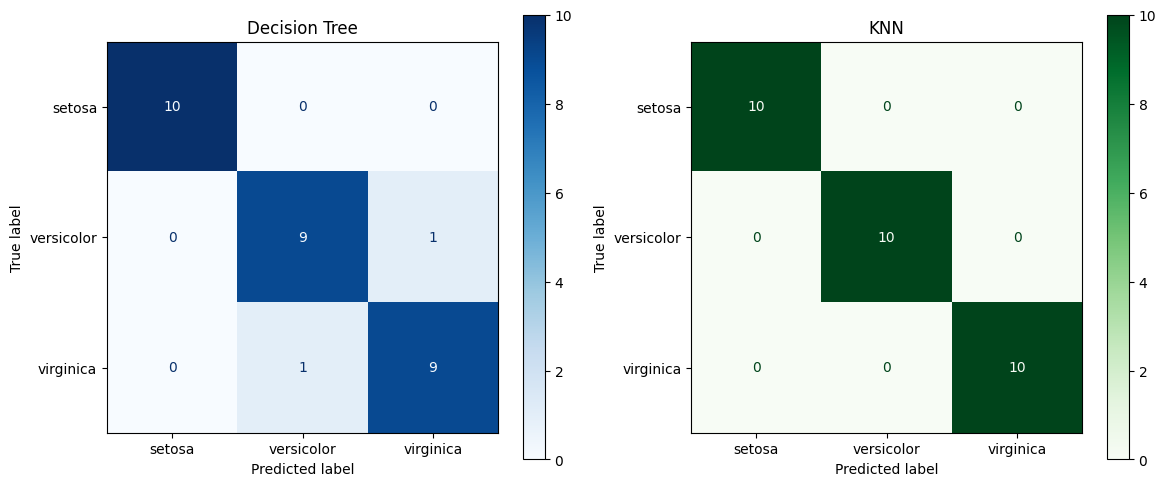

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Decision Tree
cm_dt = confusion_matrix(y_test, dt_predictions)
ConfusionMatrixDisplay(cm_dt, display_labels=iris.target_names)\
.plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Decision Tree")
# KNN
cm_knn = confusion_matrix(y_test, knn_predictions)
ConfusionMatrixDisplay(cm_knn, display_labels=iris.target_names)\
.plot(ax=axes[1], cmap="Greens")
axes[1].set_title("KNN")
plt.tight_layout()
plt.show()


Task 4: Compare the Models
1. Which model achieved higher accuracy?

**KNN achieved higher accuracy**

2. The Hardest Class to Classify\
**The hardest classes to distinguish are Versicolor and Virginica.**


3. Medical Diagnosis: Precision vs. Recall

**In medicine, a False Negative (missing a sick patient) is dangerous. High Recall ensures you catch as many cases as possible, even if it results in some false alarms (lower Precision).**

Part 6: Predicting New Samples

In [62]:
import numpy as np
# A new flower measurement (sepal_l, sepal_w, petal_l, petal_w)
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])
# Predict with both models
dt_pred = dt_model.predict(new_flower)
knn_pred = knn_model.predict(new_flower)
print(f"Decision Tree says: {iris.target_names[dt_pred[0]]}")
print(f"KNN says: {iris.target_names[knn_pred[0]]}")

Decision Tree says: setosa
KNN says: setosa


Task 5: Predict New Flowers


In [63]:
import numpy as np

# Define the three flowers in a 2D array (rows=flowers, columns=features)
flowers = np.array([
    [6.7, 3.0, 5.2, 2.3], # Flower A
    [5.8, 2.7, 4.1, 1.0], # Flower B
    [4.9, 3.1, 1.5, 0.1]  # Flower C
])

flower_labels = ['Flower A', 'Flower B', 'Flower C']

# Generate predictions for all three at once
dt_preds = dt_model.predict(flowers)
knn_preds = knn_model.predict(flowers)

print("--- Prediction Results ---")
for i in range(len(flowers)):
    dt_name = iris.target_names[dt_preds[i]]
    knn_name = iris.target_names[knn_preds[i]]

    print(f"{flower_labels[i]}:")
    print(f"  Decision Tree says: {dt_name}")
    print(f"  KNN says:           {knn_name}")

    if dt_name == knn_name:
        print("  Status: Agreement ✅")
    else:
        print("  Status: DISAGREEMENT ❌")
    print("-" * 25)

--- Prediction Results ---
Flower A:
  Decision Tree says: virginica
  KNN says:           virginica
  Status: Agreement ✅
-------------------------
Flower B:
  Decision Tree says: versicolor
  KNN says:           versicolor
  Status: Agreement ✅
-------------------------
Flower C:
  Decision Tree says: setosa
  KNN says:           setosa
  Status: Agreement ✅
-------------------------


8.1 Step 1: Create a Sample CSV


In [66]:
import pandas as pd
import numpy as np
# Create a simple student performance dataset
np.random.seed(42)
n = 100
data = {
"study_hours": np.round(np.random.uniform(1, 10, n), 1),
"attendance_pct": np.round(np.random.uniform(40, 100, n), 1),
"assignments": np.random.randint(3, 10, n),
"passed": np.random.choice([0, 1], n, p=[0.35, 0.65])
}
df = pd.DataFrame(data)
df.to_csv("students.csv", index=False)
print("CSV saved! First 5 rows:")
print(df.head())


CSV saved! First 5 rows:
   study_hours  attendance_pct  assignments  passed
0          4.4            41.9            6       0
1          9.6            78.2            5       1
2          7.6            58.9            3       1
3          6.4            70.5            6       1
4          2.4            94.5            8       1


8.2 Step 2: Load the CSV with Pandas


In [67]:
import pandas as pd
# Read the CSV file
df = pd.read_csv("students.csv")
# Quick exploration
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nBasic stats:\n{df.describe()}")

Shape: (100, 4)

Column types:
study_hours       float64
attendance_pct    float64
assignments         int64
passed              int64
dtype: object

Basic stats:
       study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
min       1.000000       40.400000     3.000000    0.000000
25%       2.775000       54.500000     4.750000    0.000000
50%       5.150000       70.350000     6.000000    1.000000
75%       7.600000       85.975000     8.000000    1.000000
max       9.900000       99.100000     9.000000    1.000000


8.3 Step 3: Prepare Features and Target


In [69]:
# Features = all columns except "passed"
X = df[["study_hours", "attendance_pct", "assignments"]].values
# Target = the "passed" column
y = df["passed"].values
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class counts: {np.unique(y, return_counts=True)}")


Features shape: (100, 3)
Target shape: (100,)
Class counts: (array([0, 1]), array([31, 69]))


8.4 Step 4: Apply the Full Workflow


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
# Split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
# Train
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
# Predict & Evaluate
predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
print(classification_report(y_test, predictions,
target_names=["Failed", "Passed"]))


Accuracy: 55.00%
              precision    recall  f1-score   support

      Failed       0.33      0.50      0.40         6
      Passed       0.73      0.57      0.64        14

    accuracy                           0.55        20
   macro avg       0.53      0.54      0.52        20
weighted avg       0.61      0.55      0.57        20



Task 6: CSV Challenge


In [97]:
#Load the dataset
df = pd.read_csv("students.csv")


# Explore
print(df.info())
print(df.describe())

# Prepare Data
X = df[['study_hours', 'attendance_pct', 'assignments']]
y = df['passed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt_model.predict(X_test))

# 2. KNN (K-Nearest Neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn_model.predict(X_test))

print(f"Decision Tree Accuracy: {dt_acc:.2%}")
print(f"KNN Accuracy: {knn_acc:.2%}")

# 3. Add new feature
df['quiz_score'] = np.random.randint(50, 100, n)

# Update X to include the new column
X_new = df[['study_hours', 'attendance_pct', 'assignments', 'quiz_score']]

# Retrain (using Decision Tree as an example)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_new, y, test_size=0.2, random_state=42)
new_model = DecisionTreeClassifier(random_state=42)
new_model.fit(X_train_n, y_train_n)

print(f"New Accuracy with Quizzes: {accuracy_score(y_test_n, new_model.predict(X_test_n)):.2%}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     100 non-null    float64
 1   attendance_pct  100 non-null    float64
 2   assignments     100 non-null    int64  
 3   passed          100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB
None
       study_hours  attendance_pct  assignments      passed
count   100.000000      100.000000   100.000000  100.000000
mean      5.233000       69.871000     6.000000    0.690000
std       2.681438       17.583476     1.959179    0.464823
min       1.000000       40.400000     3.000000    0.000000
25%       2.775000       54.500000     4.750000    0.000000
50%       5.150000       70.350000     6.000000    1.000000
75%       7.600000       85.975000     8.000000    1.000000
max       9.900000       99.100000     9.000000    1.000000
Decision Tree Accuracy: 55.00%
K

after adding column No, the accuracy did not improve; it actually decreased.

TASK 6 **BONUS**

In [91]:
# 1. Load the data
df = pd.read_csv('/content/Titanic-Dataset.csv')

# 2. Basic Preprocessing
# Fill missing 'Age' values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Convert 'Sex' to numbers (0 for female, 1 for male)
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

# Select features (X) and target (y)
# Common Titanic features: Pclass, Sex, Age, SibSp (siblings), Parch (parents/children)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']
X = df[features]
y = df['Survived']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data ready! Training on {len(X_train)} rows, Testing on {len(X_test)} rows.")

# Train Decision Tree
dt_titanic = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_titanic.fit(X_train, y_train)
dt_pred = dt_titanic.predict(X_test)

# Train KNN
knn_titanic = KNeighborsClassifier(n_neighbors=5)
knn_titanic.fit(X_train, y_train)
knn_pred = knn_titanic.predict(X_test)

# Results
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.2%}")
print(f"KNN Accuracy: {accuracy_score(y_test, knn_pred):.2%}")

Data ready! Training on 712 rows, Testing on 179 rows.
Decision Tree Accuracy: 81.01%
KNN Accuracy: 76.54%
